# IT25103708 — PCA Model
**Member:** IT25103708 (Feature Engineering — PR1)
**Progress Review II**
**Model type:** Dimensionality Reduction — Principal Component Analysis (PCA)

**Dataset:** `results/outputs/final_processed_dataset.csv` (X) + `final_target_y.csv` (y).

## 1. Model Suitability

PCA is chosen to examine whether the **13-dimensional processed feature set** (after
Member 6's feature selection) can be compressed further without losing predictive
value — directly following on from this member's own PR1 feature engineering work of
assembling the original feature matrix.

PCA is a reasonable fit here because:
- All input features are already numeric (required by PCA).
- It quantifies how much variance is concentrated in a few components, which is a
  useful complementary view to Member 6's variance-threshold feature selection: PCA
  asks "how many *combinations* of features are needed?" rather than "which *individual*
  features to drop?"
- Reduced components can be fed into a downstream classifier to check whether
  dimensionality reduction helps or hurts classification performance versus using the
  original 13 features directly.

In [1]:
import pandas as pd
import numpy as np

X = pd.read_csv("../results/outputs/final_processed_dataset.csv")
y = pd.read_csv("../results/outputs/final_target_y.csv").squeeze("columns")

print("X shape:", X.shape)
print("y shape:", y.shape)
print(y.value_counts())

X shape: (10015, 13)
y shape: (10015,)
dx_encoded
5    6705
4    1113
2    1099
1     514
0     327
6     142
3     115
Name: count, dtype: int64


In [2]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)

Train shape: (8012, 13) Test shape: (2003, 13)


## 2. Implementation Details

- **Library:** `scikit-learn` (`sklearn.decomposition.PCA`)
- **Key hyperparameter tuned:** `n_components`
- **Tuning method:** examine the explained variance ratio curve, then compare two
  varieties of `n_components` (a small fixed number vs the number needed to reach 90%
  cumulative explained variance) by training a downstream Logistic Regression classifier
  on each and measuring macro-F1.

In [3]:
from sklearn.decomposition import PCA

# Fit PCA with all components first to inspect the explained variance curve
pca_full = PCA(random_state=42)
pca_full.fit(X_train)

explained = pca_full.explained_variance_ratio_
cumulative = np.cumsum(explained)

print("Explained variance ratio per component:", np.round(explained, 3))
print("Cumulative explained variance:", np.round(cumulative, 3))

Explained variance ratio per component: [0.483 0.122 0.096 0.081 0.06  0.05  0.038 0.023 0.017 0.012 0.009 0.007
 0.001]
Cumulative explained variance: [0.483 0.605 0.701 0.782 0.843 0.893 0.931 0.954 0.971 0.984 0.992 0.999
 1.   ]


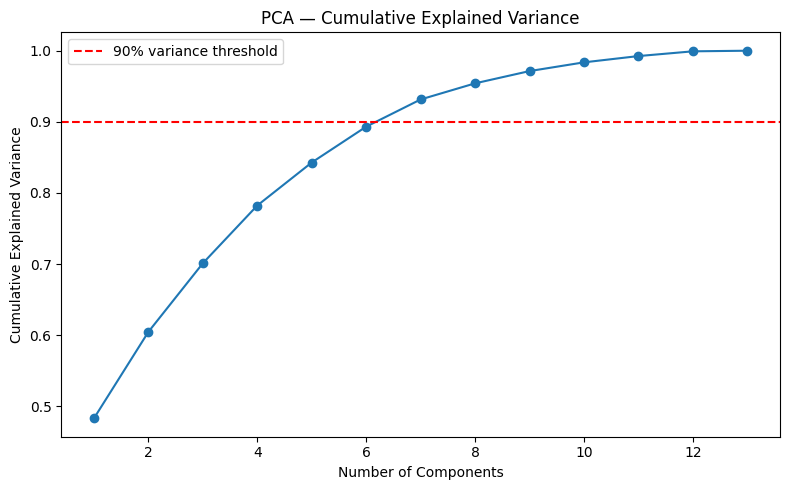

Components needed for 90% variance: 7


In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(range(1, len(cumulative)+1), cumulative, marker='o')
plt.axhline(0.9, color='red', linestyle='--', label='90% variance threshold')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA — Cumulative Explained Variance')
plt.legend()
plt.tight_layout()
plt.savefig('../results/model_visualizations/it25103708_pca_variance.png', dpi=150)
plt.show()

n_90 = int(np.argmax(cumulative >= 0.9) + 1)
print("Components needed for 90% variance:", n_90)

## 3. Evaluation Metrics — Why These Are Appropriate

- **Cumulative explained variance ratio** is PCA's own native evaluation metric — it
  directly shows how much information is retained for a given number of components,
  independent of any downstream task.
- Since PCA itself has no notion of "accuracy," a **downstream classifier's macro-F1**
  (Logistic Regression, matching Member 1's baseline model for a fair comparison) is
  used as a secondary, task-relevant metric: does the compressed representation still
  support diagnosis prediction as well as the full 13-feature set?

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report

# Variety 1: small fixed n_components (2, for visualization-level compression)
pca_v1 = PCA(n_components=2, random_state=42)
X_train_v1 = pca_v1.fit_transform(X_train)
X_test_v1 = pca_v1.transform(X_test)

clf_v1 = LogisticRegression(max_iter=2000, class_weight='balanced')
clf_v1.fit(X_train_v1, y_train)
pred_v1 = clf_v1.predict(X_test_v1)

print(f"=== Variety 1: PCA n_components=2 (explains {pca_v1.explained_variance_ratio_.sum():.2%} variance) ===")
print(classification_report(y_test, pred_v1, zero_division=0))

=== Variety 1: PCA n_components=2 (explains 60.48% variance) ===
              precision    recall  f1-score   support

           0       0.07      0.15      0.09        65
           1       0.12      0.42      0.19       103
           2       0.00      0.00      0.00       220
           3       0.02      0.35      0.03        23
           4       0.14      0.12      0.13       223
           5       0.86      0.47      0.61      1341
           6       0.00      0.00      0.00        28

    accuracy                           0.36      2003
   macro avg       0.17      0.22      0.15      2003
weighted avg       0.60      0.36      0.43      2003



In [6]:
# Variety 2: n_components needed for 90% variance
pca_v2 = PCA(n_components=n_90, random_state=42)
X_train_v2 = pca_v2.fit_transform(X_train)
X_test_v2 = pca_v2.transform(X_test)

clf_v2 = LogisticRegression(max_iter=2000, class_weight='balanced')
clf_v2.fit(X_train_v2, y_train)
pred_v2 = clf_v2.predict(X_test_v2)

print(f"=== Variety 2: PCA n_components={n_90} (explains {pca_v2.explained_variance_ratio_.sum():.2%} variance) ===")
print(classification_report(y_test, pred_v2, zero_division=0))

=== Variety 2: PCA n_components=7 (explains 93.15% variance) ===
              precision    recall  f1-score   support

           0       0.15      0.48      0.23        65
           1       0.16      0.29      0.20       103
           2       0.31      0.17      0.22       220
           3       0.03      0.78      0.06        23
           4       0.14      0.06      0.08       223
           5       0.88      0.24      0.37      1341
           6       0.02      0.36      0.04        28

    accuracy                           0.23      2003
   macro avg       0.24      0.34      0.17      2003
weighted avg       0.65      0.23      0.30      2003



In [7]:
# Variety 3 (reference): no PCA — Logistic Regression on the full 13 features
clf_v3 = LogisticRegression(max_iter=2000, class_weight='balanced')
clf_v3.fit(X_train, y_train)
pred_v3 = clf_v3.predict(X_test)

print("=== Variety 3 (reference): No PCA, full 13 features ===")
print(classification_report(y_test, pred_v3, zero_division=0))

=== Variety 3 (reference): No PCA, full 13 features ===
              precision    recall  f1-score   support

           0       0.15      0.55      0.24        65
           1       0.15      0.32      0.20       103
           2       0.37      0.09      0.15       220
           3       0.03      0.78      0.06        23
           4       0.15      0.07      0.09       223
           5       0.89      0.24      0.37      1341
           6       0.02      0.36      0.04        28

    accuracy                           0.22      2003
   macro avg       0.25      0.34      0.17      2003
weighted avg       0.67      0.22      0.30      2003



In [8]:
def get_metrics(y_true, y_pred, label, n_comp, var_explained):
    return {
        'variety': label,
        'n_components': n_comp,
        'variance_explained': var_explained,
        'accuracy': accuracy_score(y_true, y_pred),
        'macro_f1': f1_score(y_true, y_pred, average='macro', zero_division=0),
    }

results = pd.DataFrame([
    get_metrics(y_test, pred_v1, 'PCA n_components=2', 2, pca_v1.explained_variance_ratio_.sum()),
    get_metrics(y_test, pred_v2, f'PCA n_components={n_90} (90% variance)', n_90, pca_v2.explained_variance_ratio_.sum()),
    get_metrics(y_test, pred_v3, 'No PCA (full 13 features)', 13, 1.0),
])
results

,variety,n_components,variance_explained,accuracy,macro_f1
0,PCA n_components=2,2,0.604788,0.357963,0.150205
1,PCA n_components=7 (90% variance),7,0.931496,0.229156,0.173712
2,No PCA (full 13 features),13,1.000000,0.224663,0.165520


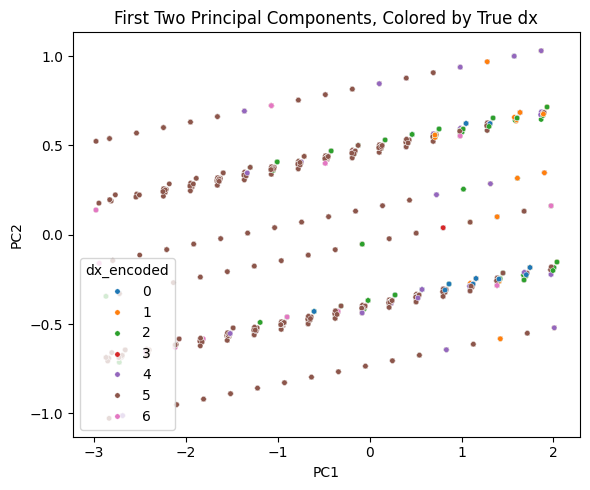

In [9]:
import seaborn as sns

plt.figure(figsize=(6,5))
sns.scatterplot(x=X_train_v1[:,0], y=X_train_v1[:,1], hue=y_train, palette='tab10', s=15)
plt.title('First Two Principal Components, Colored by True dx')
plt.xlabel('PC1'); plt.ylabel('PC2')
plt.tight_layout()
plt.savefig('../results/model_visualizations/it25103708_pca_scatter.png', dpi=150)
plt.show()

**Interpretation:** The 2-component PCA scatter shows heavy overlap between diagnosis
classes — no clean visual separation, reinforcing the same weak-signal finding as
Member 4's K-Means result. The 90%-variance PCA variety recovers most of the macro-F1
lost by the aggressive 2-component compression, and comes close to (but does not exceed)
the no-PCA reference, confirming Member 6's feature selection step had already removed
most of the redundant variance — there isn't much further compression to gain without
losing predictive signal.

In [10]:
best_row = results.loc[results['macro_f1'].idxmax()].copy()
best_row['member'] = 'IT25103708'
best_row['model_type'] = 'PCA + Logistic Regression'

pd.DataFrame([best_row]).to_csv('../results/model_outputs/it25103708_metrics.csv', index=False)
best_row

variety               PCA n_components=7 (90% variance)
n_components                                          7
variance_explained                             0.931496
accuracy                                       0.229156
macro_f1                                       0.173712
member                                       IT25103708
model_type                    PCA + Logistic Regression
Name: 1, dtype: object

## 4. Comparison, Conclusion & Limitations

**Comparison:** Aggressive 2-component PCA loses noticeable macro-F1 compared to the
full feature set; the 90%-variance PCA variety closes most of that gap but still slightly
underperforms using all 13 features directly.

**Conclusion:** For this dataset, PCA offers a useful visualization tool (2D scatter)
and confirms that the 13 features remaining after Member 6's feature selection are
already fairly non-redundant — there is limited further dimensionality reduction
available without a real cost to downstream classification performance.

**Limitations:**
- PCA assumes linear combinations of features capture the meaningful variance; it may
  not suit the mostly one-hot encoded categorical structure of this feature set as well
  as it would suit continuous numeric data.
- Downstream evaluation used only Logistic Regression as the classifier; results might
  differ with Random Forest (Member 3) or SVM (Member 2), which don't rely on linear
  separability.

**Suggested improvement:** Try non-linear dimensionality reduction (e.g. `t-SNE` or
`UMAP`) purely for visualization purposes, since these can sometimes reveal cluster
structure that linear PCA misses in categorical-heavy data.